In [5]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd


class Get_Stock_data():
    def __init__(self,symbol,start_day,end_day=None):
        self.symbol = symbol
        self.start_day = start_day
        self.end_day = end_day
        self.test_data = pd.DataFrame()
        self.train_data = pd.DataFrame()
        try:
            self.StockName = self.symbol.split("^")[1]
        except IndexError:
            self.StockName = self.symbol

        if self.StockName == "GDAXI":
            self.StockName = "DAX"
        elif self.StockName == "GSPC":
            self.StockName = "S&P_500"
        elif self.StockName == "DJI":
            self.StockName = "Dow_Jones"
        elif self.StockName == "IXIC":
            self.StockName = "NASDAQ"
        elif self.StockName == "SOX":
            self.StockName = "PHLX"
   
    def getdata(self):
        self.stockdata = yf.download(self.symbol, self.start_day, self.end_day, auto_adjust=False)
        
        if self.stockdata.empty:
            print(f"Failed to download data for {self.symbol}")
            return
        self.stockdata = self.stockdata.sort_index(ascending=True)
        # 刪除多層索引中的 Ticker 層
        if isinstance(self.stockdata.columns, pd.MultiIndex):
            self.stockdata.columns = self.stockdata.columns.droplevel(1)
        # 確保索引是 DatetimeIndex 對象
        self.stockdata.index = pd.to_datetime(self.stockdata.index)

        # 轉換Date格式為yyyymmdd
        self.stockdata.index = self.stockdata.index.strftime("%Y%m%d")
        # 將label轉換為小寫以符合talib所需的格式
        self.stockdata.columns = self.stockdata.columns.str.lower()
        self.stockdata.rename_axis("date", axis=0, inplace=True)
        output_data = pd.DataFrame(self.stockdata)
        # 當天價格變化
        # output_data["change"] = 100 * (output_data["close"] - output_data["open"]) / output_data["open"]
        # 計算今天與昨天的收盤價變化百分比
        output_data["change"] = output_data["close"].pct_change() * 100
        # 將 NaN 填充為 0，避免使用 inplace=True
        output_data["change"] = output_data["change"].fillna(0)
        
        self.test_data = output_data

        # output_data = output_data[output_data.index <= "20241231"]
        
        
        # output_data = output_data[["close","change"]]

        # self.test_data = output_data[(output_data.index >= "20210101")]
        # 將數據保存到csv文件中
        output_data.to_csv(f"StockData/{self.StockName}.csv")   
        # print(f"{self.StockName} data_length:{len(self.stockdata["close"])}")

        return self.test_data
        

if __name__ == "__main__":
    
    symbol = ["^GSPC","^DJI","^IXIC","^SOX","^N225","^TWII","000001.SS","^GDAXI","^FTSE","^FCHI"]
    start = "1900-01-01"
    end = ""
    stockdata = pd.DataFrame()
    train_data, test_data = pd.DataFrame(), pd.DataFrame()

    
    for s in symbol:
        if s == "^TWII":
            test_data = Get_Stock_data(s, start).getdata()
            test_data.to_csv(f"StockData/test_data.csv")   
        else:
            _ = Get_Stock_data(s, start).getdata()
            
    
     



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


test_data_length:1087
change_sum:-442.58124157774193


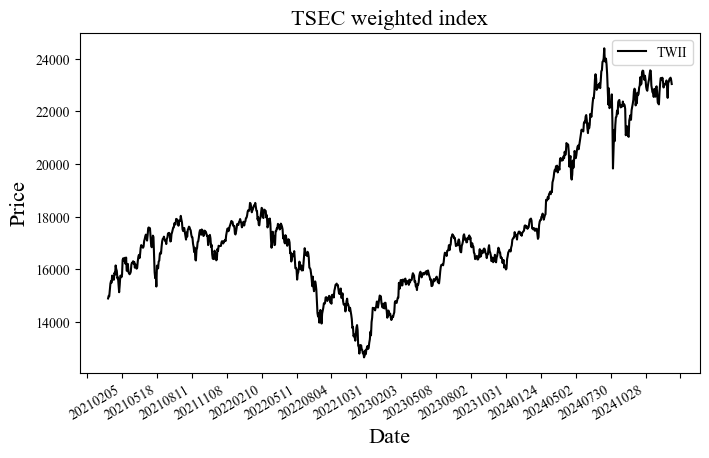

In [7]:
print(f"test_data_length:{len(test_data)}")
print(f"change_sum:{test_data["change"][test_data["change"] < 0].sum()}")

test_data = test_data[test_data.index >= "20210101"]
up_trend = test_data[(test_data.index >= "20210101") & (test_data.index <= "20210331")] # 上升趨勢
flat_trend = test_data[(test_data.index >= "20241001") & (test_data.index <= "20241231")] # 盤整趨勢
down_trend = test_data[(test_data.index >= "20220401") & (test_data.index <= "20220630")] # 下跌趨勢
# all_trend = test_data[(test_data.index >= "20250101") & (test_data.index <= "20250531")] # 2025年上半年
all_trend = test_data[(test_data.index >= "20210101") & (test_data.index <= "20241231")] # 2021-2024

# 設置字體為 Times New Roman
plt.rcParams["font.family"] = "Times New Roman"
plt.figure(figsize=(8, 5))
plt.plot(all_trend.index, all_trend["close"], label="TWII", color="black")
# 設置日期格式
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=60))
plt.gcf().autofmt_xdate()  # 自動旋轉日期標籤

plt.title("TSEC weighted index", fontsize=16)
plt.xlabel("Date", fontsize=16)
plt.ylabel("Price", fontsize=16)
plt.legend()
plt.savefig("./picture/TSEC_testdata.png")
plt.show()